In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [244]:
df = pd.read_csv("block_tem_faquarson.csv")
df_half = pd.read_csv("half_tem_faquarson.csv")

In [245]:
times = df['times_s'].values
area = 100*100
radius = np.sqrt(area/np.pi)

In [246]:
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps

# Receiver geometry
receiver_location = np.r_[0., 0., 0.] # or (N, 3) numpy.ndarray
# source_location = np.array([0., 0., 0.])
dx = 100.
dy = 100.
dx1 = np.array([-dx/2, -dy/2, 0.])
dx2 = np.array([-dx/2, +dy/2, 0.])
dx3 = np.array([+dx/2, +dy/2, 0.])
dx4 = np.array([+dx/2, -dy/2, 0.])
source_locations = np.vstack((dx1, dx2, dx3, dx4, dx1))

receiver_orientation = "z"  # "x", "y" or "z"

# Receiver list
receiver_list = []
receiver_list.append(
    tdem.receivers.PointMagneticFluxTimeDerivative(
        receiver_location, times, orientation=receiver_orientation
    )
)

# Define the source waveform.
waveform = tdem.sources.StepOffWaveform()

# Sources
source_list = [
    tdem.sources.LineCurrent(
        receiver_list=receiver_list,
        location=source_locations,
        waveform=waveform, 
        # radius=radius
    )
]

# Survey
survey = tdem.Survey(source_list)

simulation_L2 = tdem.Simulation1DLayered(
    survey=survey, sigmaMap=maps.IdentityMap(nP=1)
)
sigma = np.ones(1) * 0.1

In [247]:
dpred = simulation_L2.dpred(sigma)

In [248]:
simulation_L2.sigma

array([0.1])

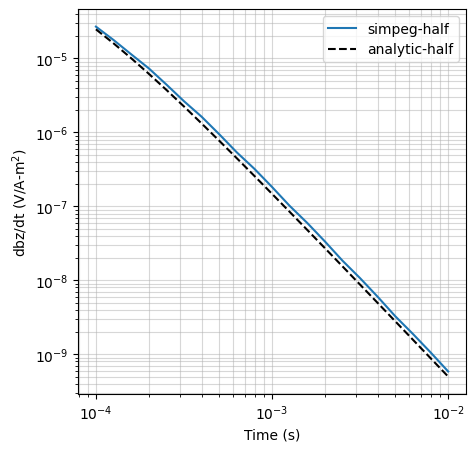

In [255]:
factor = 1
fig = plt.figure(figsize=(5,5))
# plt.loglog(df['times_s'], df['voltage_V_Am2']*factor, label='simpeg-block')
plt.loglog(df['times_s'], df_half['voltage_V_Am2']*factor, '-', label='simpeg-half')
plt.loglog(df['times_s'], dpred, 'k--', label='analytic-half')
plt.grid(True, which='both', alpha=0.5)
# plt.xlim(6e-5, 1e-2)
# plt.ylim(3e-10, 1e-4)
plt.xlabel("Time (s)")
plt.ylabel("dbz/dt (V/A-m$^2$)")
plt.legend()

In [254]:
pd.DataFrame(
    data=np.c_[times, dpred, df_half['voltage_V_Am2'].values, df['voltage_V_Am2'].values],
    columns=['times_s', 'halfsapce_analytic', 'simpeg_halfspace', 'simpeg_block']
).to_csv("comparision_simpeg.csv", index=False)